In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("helgrind113/logistics-risk-and-fraud")

print("Path to dataset files:", path)

C:\Users\настя\pandas\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 546k/546k [00:01<00:00, 523kB/s]

Extracting files...
Path to dataset files: C:\Users\настя\.cache\kagglehub\datasets\helgrind113\logistics-risk-and-fraud\versions\1


In [8]:
import pandas as pd

df = pd.read_excel("C:/Users/настя/.cache/kagglehub/datasets/helgrind113/logistics-risk-and-fraud/versions/1/dataset.xlsx")

In [12]:
import seaborn as sns
from matplotlib import pyplot as plt

In [ ]:
print(df.head(10))
print(df.shape)
print(df.describe())
print(df.info())

In [10]:
status = df.groupby('Granular Status').count()
status

,Tracking ID,Cod Value,Creation Datetime,Delivery Success Datetime,Delivery Success Hub ID,From Address2,pickup hub id,To Address2,Shop Name,Rider Name
Granular Status,,,,,,,,,,
Completed,12951,12951,12951,12951,12951,11319,12951,11899,12951,12951
Returned to Sender,101,101,101,101,101,66,101,66,101,101


In [48]:
worker_del = df.groupby('Rider Name')['Tracking ID'].count()
shop_del = df.groupby("Shop Name")['Tracking ID'].count()
worker_del = worker_del.sort_values(ascending=False)
shop_del = shop_del.sort_values(ascending=False)

<Axes: xlabel='pickup hub id', ylabel='count'>

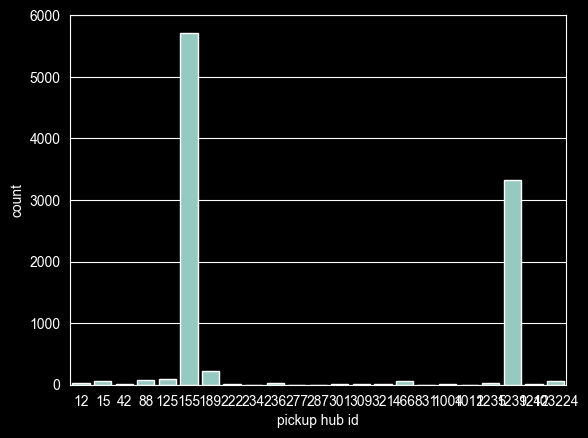

In [92]:
top_shop = shop_del.iloc[0:10]
top_shop_name = top_shop.index[0:10]
shop = df[df['Shop Name'].isin(top_shop_name)]
pickup = shop.groupby('pickup hub id').size().reset_index(name='count')
sns.barplot(data=pickup, x='pickup hub id', y='count')

In [118]:
pickup_top = pickup.sort_values(by='count', ascending=False)
pickup_top = pickup_top.iloc[0:3]
pickup_top = pickup_top['pickup hub id']
pt = pickup_top.tolist()
names = df[df['pickup hub id'].isin(pt)]
name = names.groupby('Rider Name').size().reset_index(name='count')
name.sort_values(by='count', ascending=False)

,Rider Name,count
91,238-NEXT-VV,5674
55,155-AGAR-DTT,1758
94,242-NEXT-DH,1562
34,1210-NEXT-NTA,33
104,74-NEXT-PH Ph,30
...,...,...
96,242-NEXT-VT V,2
108,823-NEXT-NG H,2
99,74-NEXT-LQ Kh,2
18,104533-NEXT-H,1
